# 04 — Ranking de Sistemas

**Objetivo:** consolidar a qualidade dos sistemas em **dois rankings**:

1. **Ranking de confiabilidade** — avalia exclusivamente a qualidade dos telefones via `P(Telefone HighDelivery | sistema)`.
2. **Ranking operacional** — combina qualidade com o **volume relativo de telefones fornecidos**, refletindo o potencial de alcance de cada sistema na base total.

## Convenção de classificação

- **HighDelivery**: taxa de entrega (`status ∈ {delivered, read}`) ≥ **90%**.
- **HighRead**: taxa de leitura (`status == read`) ≥ **75%**.

Este notebook usa **Telefone HighDelivery** como métrica de qualidade.

Insumo: `disparos_sistema.parquet` (gerado pelo notebook `01_preprocessing.ipynb`).

**Observações:**

- O notebook `03_janela_atualidade.ipynb` mostrou que a relação entre tempo desde a última atualização e qualidade dos telefones varia entre os sistemas, com padrões distintos que seriam difíceis de comparar de forma consistente. Por esse motivo, a variável de atualidade não foi incorporada na avaliação de confiabilidade entre sistemas.

- Optou-se por utilizar **HighDelivery** (taxa de entrega ≥ 90%) em vez de **HighRead** como critério de qualidade entre sistemas. A taxa de entrega reflete diretamente a capacidade do sistema de fornecer contatos válidos e alcançáveis, enquanto a taxa de leitura depende de fatores externos, como o perfil do usuário, o conteúdo da mensagem e o momento do disparo.

- A criação do ranking operacional busca incorporar a dimensão de escala. Um sistema pode apresentar alta confiabilidade, mas, se contribuir com poucos telefones, seu impacto no alcance total da campanha é limitado. Assim, ao combinar qualidade e volume, o ranking operacional permite identificar sistemas que, além de confiáveis, têm maior capacidade de atingir um número mais amplo de cidadãos, o que pode ser especialmente relevante dependendo do objetivo da campanha.

## Setup

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

OUT_DIR = Path('../outputs/processed')
DELIVERABLES_DIR = Path('../deliverables')
DELIVERABLES_DIR.mkdir(parents=True, exist_ok=True)

df_disparos_sistema = pd.read_parquet(OUT_DIR / 'disparos_sistema.parquet')
print(f'df_disparos_sistema: {df_disparos_sistema.shape}')

STATUS_SUCESSO = ['delivered', 'read']
LIMIAR_HIGH_DELIVERY = 0.9

df_disparos_sistema: (748675, 20)


## 1. Métricas por telefone 
Para cada par `(sistema, telefone)`, calculamos a **taxa de entrega** e a **taxa de falha**.

- **Taxa de entrega:** proporção de disparos com status ∈ {`delivered`, `read`}.
- **Taxa de falha:** proporção de disparos que não resultaram em entrega, ou seja, status fora de {`delivered`, `read`}.


In [ ]:
df_tel = (
    df_disparos_sistema
    .assign(
        entrega=lambda x: x['status_disparo'].isin(STATUS_SUCESSO).astype(int),
        falha=lambda x: (x['status_disparo'] == 'failed').astype(int),
    )
    .groupby(['id_sistema', 'sistema_nome', 'telefone_numero'])
    .agg(total_envios=('status_disparo', 'count'),
         entregas=('entrega', 'sum'),
         falhas=('falha', 'sum'))
    .reset_index()
)

df_tel['taxa_entrega'] = df_tel['entregas'] / df_tel['total_envios']
df_tel['taxa_falha'] = df_tel['falhas'] / df_tel['total_envios']
df_tel['high_delivery'] = (df_tel['taxa_entrega'] >= LIMIAR_HIGH_DELIVERY).astype(int)
df_tel['teve_falha'] = (df_tel['falhas'] > 0).astype(int)

df_tel.head()

,id_sistema,sistema_nome,telefone_numero,total_envios,entregas,falhas,taxa_entrega,taxa_falha,telefone_bom,teve_falha
0,1257277410380486863,Sistema A,10000843971088335932,1,1,0,1.0,0.0,1,0
1,1257277410380486863,Sistema A,10000855312638678978,1,1,0,1.0,0.0,1,0
2,1257277410380486863,Sistema A,10000909181938355120,1,1,0,1.0,0.0,1,0
3,1257277410380486863,Sistema A,1000094069898979170,1,1,0,1.0,0.0,1,0
4,1257277410380486863,Sistema A,10001099649735468021,1,1,0,1.0,0.0,1,0


## 2. Métricas agregadas por sistema

A partir das métricas por telefone, agregamos os resultados por sistema para obter indicadores de qualidade da base.

- **Telefone HighDelivery:** telefone com taxa de entrega ≥ 90%, onde sucesso é definido como `status ∈ {delivered, read}`.
- **Telefone com falha:** telefone que apresentou pelo menos um disparo com status `failed`.


In [ ]:
df_rank = (
    df_tel.groupby(['id_sistema', 'sistema_nome'])
    .agg(qtd_telefones=('telefone_numero', 'nunique'),
         telefones_high_delivery=('high_delivery', 'sum'),
         telefones_com_falha=('teve_falha', 'sum'))
    .reset_index()
)

df_rank['prob_high_delivery'] = df_rank['telefones_high_delivery'] / df_rank['qtd_telefones']
df_rank['prob_tel_falha'] = df_rank['telefones_com_falha'] / df_rank['qtd_telefones']
df_rank['pct_telefones'] = df_rank['qtd_telefones'] / df_rank['qtd_telefones'].sum()

df_rank

,id_sistema,sistema_nome,qtd_telefones,telefones_bons,telefones_com_falha,prob_tel_bom,prob_tel_falha,pct_telefones
0,1257277410380486863,Sistema A,122918,115776,4996,0.941896,0.040645,0.231267
1,13742676811738960007,Sistema E,135266,133454,431,0.986604,0.003186,0.254500
2,15689377901922904472,Sistema D,4680,4513,116,0.964316,0.024786,0.008805
3,18313131241423355789,Sistema F,81348,75369,4647,0.926501,0.057125,0.153054
4,3094574413675758272,Sistema B,175516,167003,5400,0.951497,0.030766,0.330229
5,4458959843028638627,Sistema C,11770,11124,333,0.945115,0.028292,0.022145


### Relação entre qualidade e risco
Avaliamos a relação entre `P(Telefone HighDelivery)` e `P(telefone com falha)` para entender se as métricas são correlacionadas ou se capturam dimensões distintas da qualidade. 

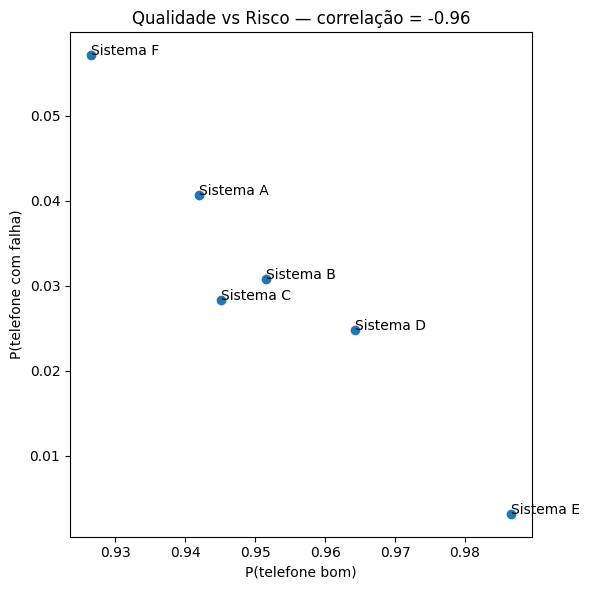

In [ ]:
corr = np.corrcoef(df_rank['prob_high_delivery'], df_rank['prob_tel_falha'])[0, 1]

plt.figure(figsize=(6, 6))
plt.scatter(df_rank['prob_high_delivery'], df_rank['prob_tel_falha'])
for _, row in df_rank.iterrows():
    plt.annotate(row['sistema_nome'],
                 (row['prob_high_delivery'], row['prob_tel_falha']))
plt.xlabel('P(Telefone HighDelivery)')
plt.ylabel('P(telefone com falha)')
plt.title(f'Qualidade vs Risco — correlação = {corr:.2f}')
plt.tight_layout()
plt.show()

> A análise mostra que as métricas são fortemente correlacionadas, com correlação de -0,96 no agregado. De forma geral, os sistemas apresentam uma relação quase linear entre `P(Telefone HighDelivery)` e `P(telefone com falha)`, com exceção do sistema C, que apresenta leve desvio desse padrão. Diante dessa forte correlação, conclui-se que `P(telefone com falha)` não adiciona informação relevante como métrica complementar no ranking de sistemas. Embora haja pequena diferença no caso do sistema C, o ganho informacional é limitado e não justifica sua incorporação.

## 3. Construção dos rankings

### 3.1. Confiabilidade
Score = `P(Telefone HighDelivery | sistema)`.

In [ ]:
df_rank_conf = (
    df_rank.assign(score=df_rank['prob_high_delivery'])
    .sort_values('score', ascending=False)
    .reset_index(drop=True)
)
df_rank_conf['ranking'] = df_rank_conf.index + 1
df_rank_conf[['ranking', 'id_sistema', 'sistema_nome', 'score']]

,ranking,id_sistema,sistema_nome,score
0,1,13742676811738960007,Sistema E,0.986604
1,2,15689377901922904472,Sistema D,0.964316
2,3,3094574413675758272,Sistema B,0.951497
3,4,4458959843028638627,Sistema C,0.945115
4,5,1257277410380486863,Sistema A,0.941896
5,6,18313131241423355789,Sistema F,0.926501


### 3.2. Operacional
Score = `0.8 * P(Telefone HighDelivery) + 0.2 * pct_telefones` (ajusta qualidade pelo
peso operacional do sistema na carteira total).

In [ ]:
W_QUALIDADE, W_VOLUME = 0.8, 0.2
df_rank_op = (
    df_rank.assign(score=W_QUALIDADE * df_rank['prob_high_delivery']
                          + W_VOLUME * df_rank['pct_telefones'])
    .sort_values('score', ascending=False)
    .reset_index(drop=True)
)
df_rank_op['ranking'] = df_rank_op.index + 1
df_rank_op[['ranking', 'id_sistema', 'sistema_nome', 'score']]

,ranking,id_sistema,sistema_nome,score
0,1,13742676811738960007,Sistema E,0.840183
1,2,3094574413675758272,Sistema B,0.827244
2,3,1257277410380486863,Sistema A,0.799770
3,4,15689377901922904472,Sistema D,0.773214
4,5,18313131241423355789,Sistema F,0.771812
5,6,4458959843028638627,Sistema C,0.760521


## 4. Persistência (entregáveis)

In [14]:
cols_export = ['ranking', 'id_sistema', 'sistema_nome', 'score']

df_rank_conf[cols_export].round(3).to_csv(
    DELIVERABLES_DIR / 'ranking_confiabilidade.csv', index=False)
df_rank_op[cols_export].round(3).to_csv(
    DELIVERABLES_DIR / 'ranking_operacional.csv', index=False)

print('Rankings exportados.')

Rankings exportados.


## 5. Comparação visual

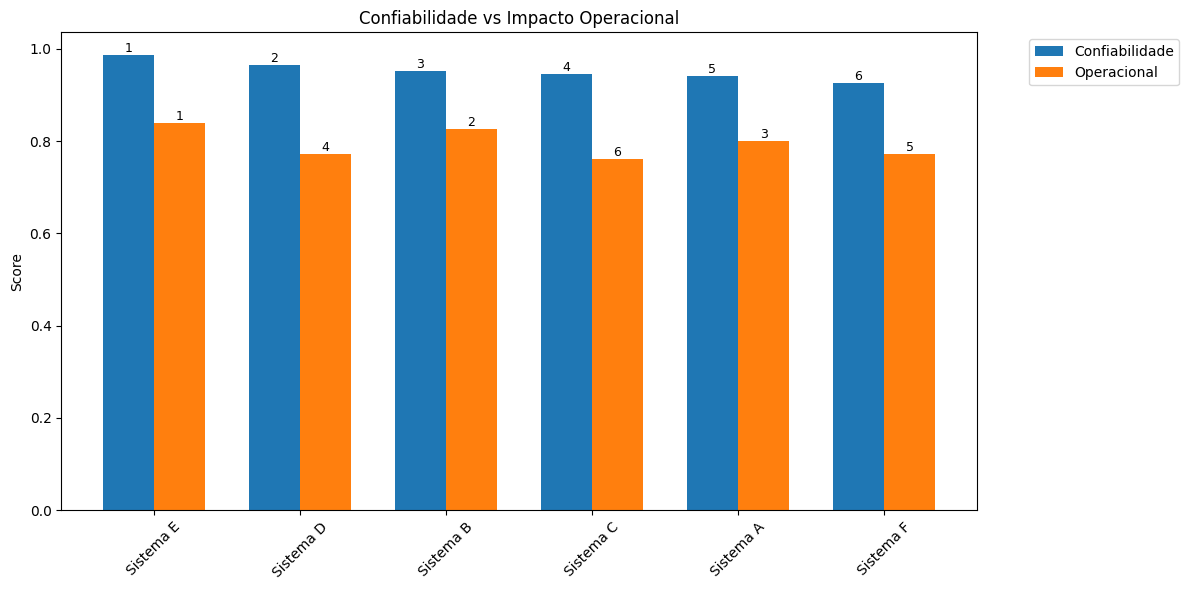

In [ ]:
df_plot = (
    df_rank_conf[['sistema_nome', 'prob_high_delivery', 'ranking']]
    .rename(columns={'ranking': 'ranking_conf'})
    .merge(
        df_rank_op[['sistema_nome', 'score', 'ranking']]
        .rename(columns={'score': 'score_operacional', 'ranking': 'ranking_op'}),
        on='sistema_nome',
    )
    .sort_values('prob_high_delivery', ascending=False)
)

x = np.arange(len(df_plot))
width = 0.35

plt.figure(figsize=(12, 6))
bars1 = plt.bar(x - width / 2, df_plot['prob_high_delivery'], width, label='Confiabilidade')
bars2 = plt.bar(x + width / 2, df_plot['score_operacional'], width, label='Operacional')

for i, bar in enumerate(bars1):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             str(df_plot['ranking_conf'].iloc[i]), ha='center', va='bottom', fontsize=9)
for i, bar in enumerate(bars2):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             str(df_plot['ranking_op'].iloc[i]), ha='center', va='bottom', fontsize=9)

plt.xticks(x, df_plot['sistema_nome'], rotation=45)
plt.ylabel('Score')
plt.title('Confiabilidade vs Impacto Operacional')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Conclusão

A métrica `P(telefone com falha)` não foi utilizada no ranking final, pois apresentou forte correlação negativa com `P(Telefone HighDelivery)` (≈ -0,96), indicando redundância. Como ambas capturam essencialmente a mesma dimensão de qualidade, sua inclusão não agregaria informação relevante nem melhoraria a discriminação entre os sistemas.

A confiabilidade foi medida por `P(Telefone HighDelivery | sistema)` (taxa de entrega ≥ 90%). No ranking de confiabilidade, o Sistema E lidera, seguido por D e B. Já no ranking operacional, que incorpora a participação relativa de cada sistema na base total de telefones, o Sistema B sobe para a segunda posição e o Sistema D perde relevância, pois, apesar de ser altamente confiável, fornece menos telefones. Isso evidencia a diferença entre qualidade e escala na priorização dos sistemas.
